**Overview**
-

This is the ipython notebook containing the analysis of the data collected from YouTube. The data was collected with the help of the YouTube Data API V3. During the collection of the data, following fixed keywords were used: "longevity", "healthy aging", "biohacking", "rejuvenation", "anti-aging", "nootropics". 

You can see the code that was used for the collection in the following cell

***Code for the data collection***

In [ ]:
from googleapiclient.discovery import build
import pandas as pd
import time

API_KEY = '***'
youtube = build('youtube', 'v3', developerKey = API_KEY)
SEARCH_TERMS = ["longevity", "healthy aging", "biohacking", "rejuvenation", "anti-aging", "nootropics"]
MAX_RESULTS = 50

def get_all_videos(query, max_pages=5):
    all_results = []
    next_page_token = None

    for _ in range(max_pages):
        search_response = youtube.search().list(
            q=query,
            part='snippet',
            publishedAfter="2010-01-01T00:00:00Z", #data was collected from 2010
            maxResults=50,
            type='video',
            pageToken=next_page_token
        ).execute()

        all_results.extend(search_response['items'])

        next_page_token = search_response.get('nextPageToken')
        if not next_page_token:
            break

    return all_results



In [ ]:
video_data = []

for term in SEARCH_TERMS:
    search_response = get_all_videos(term)
    
    for item in search_response:
        video_id = item['id']['videoId']
        title = item['snippet']['title']
        description = item['snippet']['description']
        published_at = item['snippet']['publishedAt']
        channel_title = item['snippet']['channelTitle']


        video_response = youtube.videos().list(
            part='statistics,snippet',
            id=video_id
        ).execute()

        stats = video_response['items'][0]['statistics']
        snippet = video_response['items'][0]['snippet']

        # collect the top-level comments
        try:
            comment_response = youtube.commentThreads().list(
                part='snippet',
                videoId=video_id,
                maxResults=5  
            ).execute()

            comments = [c['snippet']['topLevelComment']['snippet']['textDisplay']
                        for c in comment_response.get('items', [])]
            comment_text = " || ".join(comments)

        except:
            comment_text = ""

        

        video_data.append({
            "source": "YouTube",
            "video_id": video_id,
            "video_url": f"https://www.youtube.com/watch?v={video_id}",
            "title": title,
            "description": description,
            "date": published_at,
            "channel": channel_title,
            "comments": comment_text,
            "views": stats.get('viewCount'),
            "likes": stats.get('likeCount'),
            "comments_count": stats.get('commentCount'),
            "keywords": term,
            "country": snippet.get('defaultAudioLanguage', 'unknown')
        })
    
        time.sleep(1)  # Avoid hitting API rate limits


df = pd.DataFrame(video_data)
df.to_csv("youtube_biohacking_data.csv", index=False)
print("Done! Collected", len(df), "videos.")

With the help of the above code, 22295 videos were collected. However, after cleaning the data (deleting the duplicates, handling the NAN values).

________________________________________________________________________________________________________________________________________________________


**Analysis**
-



In [34]:
import pandas as pd
df = pd.read_csv('clean_data_new_badrows.csv', keep_default_na=False) # to prevent the pandas interpreting "" as NAN. 
df

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing
0,YouTube,qF9Ntmo6WMA,https://www.youtube.com/watch?v=qF9Ntmo6WMA,OHSHC Vitamin Love Collab (full),Full Ouran TamaXHaru Vitamin Love Collab. Hope...,EdwardEwife,you&#39;re welcome!! ^-^ || Thanks So Much!! ^...,298.0,5.0,4.0,biohacking,unknown,2010-01-01,False
1,YouTube,CLfM3skPLI8,https://www.youtube.com/watch?v=CLfM3skPLI8,Darkcore mix4,Track list: Meander - Nightfall Ophidian - Sle...,1029377525,FOORLIEF!!!!!!!<br>CD<br>xxx AD || This sounds...,14734.0,114.0,11.0,biohacking,unknown,2010-01-03,False
2,YouTube,AxcUAI3sgzo,https://www.youtube.com/watch?v=AxcUAI3sgzo,Coconut Kefir Margarita @ Longevity Conference...,Follow J-Wro on these sites (scroll down for m...,Jason Wrobel,is it a miracle or raw food that healed our gu...,1616.0,8.0,2.0,longevity,unknown,2010-01-03,False
3,YouTube,FxTc69tuOBA,https://www.youtube.com/watch?v=FxTc69tuOBA,Joe Rogan ~ DMT Is A Portal To The After Life,Joe Rogan explains his experience with DMT (Di...,Alistar Valadez,Great channel. After 5Meo I stopped lookung at...,144732.0,890.0,288.0,nootropics,unknown,2010-01-03,False
4,YouTube,Mp6qdlHJyyI,https://www.youtube.com/watch?v=Mp6qdlHJyyI,Food for Seniors,Food for seniors is an important concern. Food...,GracefulAging,,661.0,1.0,0.0,healthy aging,unknown,2010-01-03,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22290,YouTube,Fk-APD6cD54,https://www.youtube.com/watch?v=Fk-APD6cD54,"Science of Immortality- Sadhana, Diet, Yoga, L...",150+ Year-Old Rishis Live In The Himalayas | G...,SHLLOKA,The section on lokas will make ones imaginatio...,1233.0,165.0,40.0,longevity,en-IN,2025-07-19,False
22291,YouTube,TyAQZLpaCr4,https://www.youtube.com/watch?v=TyAQZLpaCr4,Il biohacking è morto. Te ne sei accorto?,Tutti ne parlano ma nessuno si chiede se abbia...,Manuel Salvadori,,491.0,1.0,0.0,biohacking,it,2025-07-19,False
22292,YouTube,fi-JQVoEbKM,https://www.youtube.com/watch?v=fi-JQVoEbKM,Discover These 5 Golden Habits for Healthy Agi...,Dear Seniors: Discover These 5 Golden Habits f...,The Story of the Elderly,,4.0,0.0,0.0,healthy aging,unknown,2025-07-19,False
22293,YouTube,FNoFRbHE7T8,https://www.youtube.com/watch?v=FNoFRbHE7T8,Provo il Biohacking per la prima volta… #bioha...,In questo video ti porto con me dentro uno dei...,Nicolò Caraffa,,1193.0,7.0,0.0,biohacking,it,2025-07-19,False


**Let's show the keyword frequency first**

In [36]:
df['keywords'].value_counts()

keywords
biohacking       3806
longevity        3770
nootropics       3734
rejuvenation     3694
healthy aging    3679
anti-aging       3612
Name: count, dtype: int64

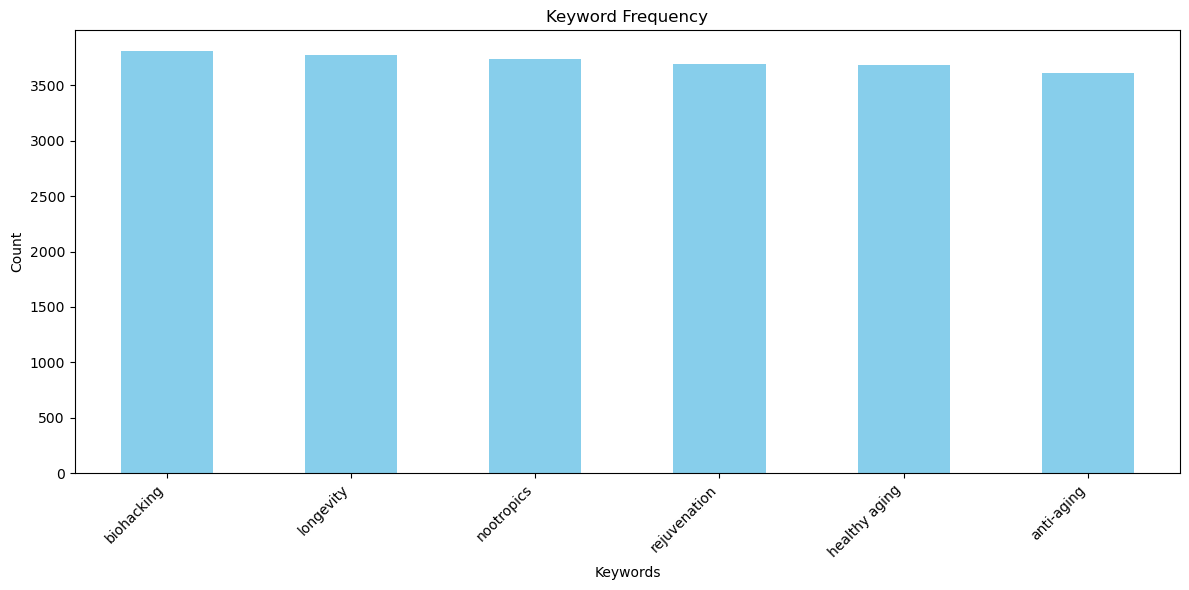

In [38]:
import matplotlib.pyplot as plt

keyword_counts = df['keywords'].value_counts()

plt.figure(figsize=(12,6))
keyword_counts.plot(kind='bar', color='skyblue')

plt.title('Keyword Frequency')
plt.xlabel('Keywords')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Time based analysis**

Let's show the number of videos for each year. 

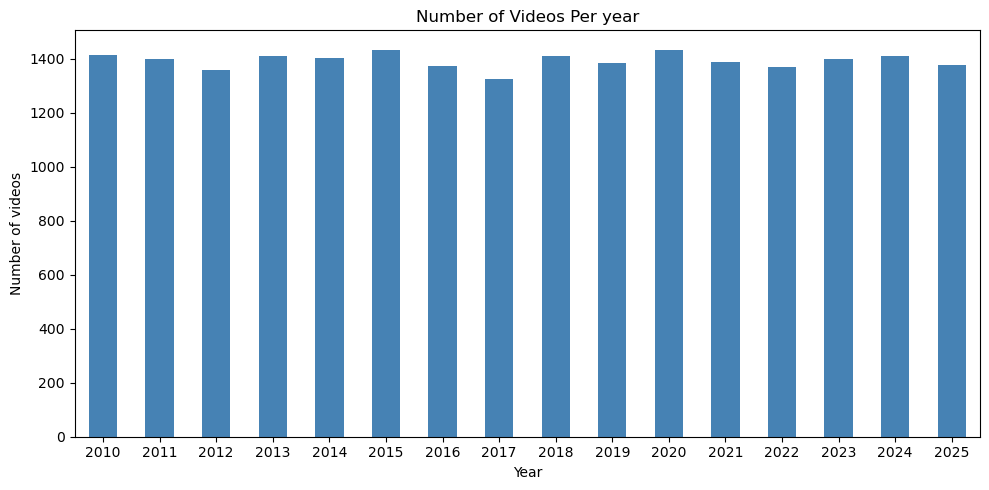

In [40]:
import matplotlib.pyplot as plt

df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['year'] = df['date'].dt.year

yearly_counts = df['year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
yearly_counts.plot(kind='bar', color='steelblue')

plt.title('Number of Videos Per year')
plt.xlabel('Year')
plt.ylabel('Number of videos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [42]:
df['year'].value_counts().sort_index()

year
2010    1416
2011    1401
2012    1359
2013    1411
2014    1403
2015    1434
2016    1375
2017    1327
2018    1409
2019    1383
2020    1433
2021    1390
2022    1369
2023    1398
2024    1410
2025    1377
Name: count, dtype: int64

**Engagement analysis**

Let's create the engagement column for each video which represents the how the users are engaged. It will be the sum of likes and comment counts

In [44]:
df['engagement']=df['likes'] + df['comments_count']

In [46]:
df.groupby('keywords')['engagement'].mean().sort_values(ascending=False)

keywords
anti-aging       5668.231728
longevity        2439.683024
rejuvenation     1793.962101
biohacking       1468.493431
healthy aging     615.955966
nootropics        409.191216
Name: engagement, dtype: float64

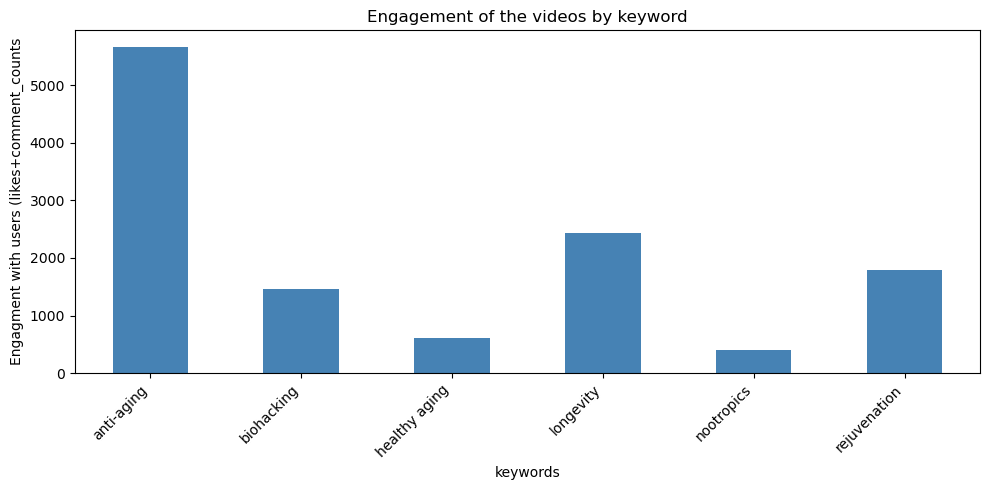

In [48]:
engagement_by_keyword = df.groupby('keywords')['engagement'].mean()

plt.figure(figsize=(10, 5))

engagement_by_keyword.plot(kind='bar', color='steelblue')

plt.title('Engagement of the videos by keyword')
plt.xlabel('keywords')
plt.ylabel('Engagment with users (likes+comment_counts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Engagement rate**

Let's create the column called 'engagement_rate'. This columsn will represent the percentage of the people who have actively engaged with the video. This can give give us the insights such as which topics (keywords) have created more discussions. The rate will be engagement/views

A video with 10,000 views and 200 total interactions (2%) may be more engaging than one with 1M views and 5,000 interactions (0.5%).

In [50]:
len(df[df['views']==0])#we need to also handle when the views are equal to 0

77

In [52]:
df['engagement_rate'] = df['engagement'] / df['views']
df.loc[df['views'] == 0, 'engagement_rate'] = 0

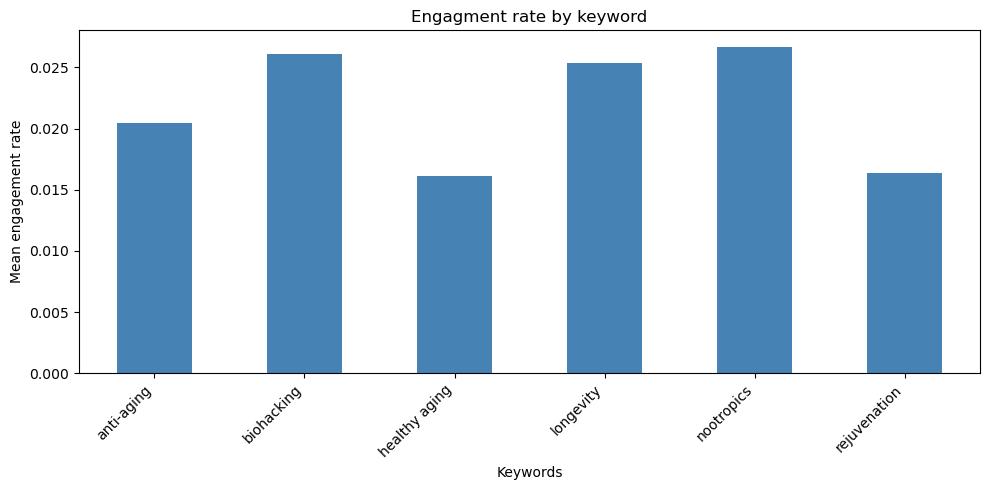

In [54]:
import matplotlib.pyplot as plt

engagement_rate_keyword = df.groupby('keywords')['engagement_rate'].mean()

plt.figure(figsize=(10, 5))

engagement_rate_keyword.plot(kind='bar', color='steelblue')
plt.title('Engagment rate by keyword')
plt.xlabel('Keywords')
plt.ylabel('Mean engagement rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The engagement rate of the "biohakcing" and "nootropics" are higher than the rest of the keywords, even though the absolute engagement of this keywords was relatively low. Which means that the videos with this topics created higher discussions. 

Engagement Over Time

<Axes: xlabel='year'>

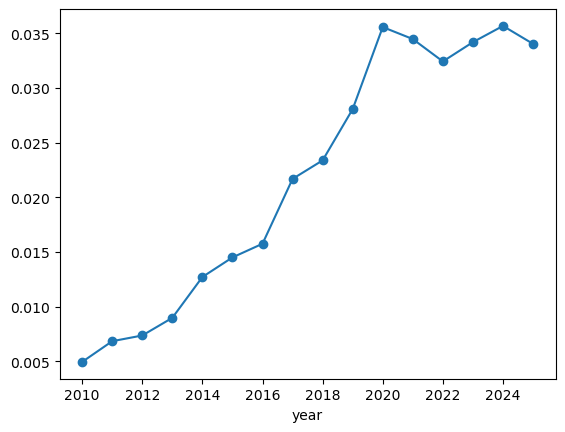

In [56]:
df.groupby('year')['engagement_rate'].mean().plot(kind='line', marker='o')


**BERTopic analysis**
--

I have used the same hyperparameters as have Isken did in his analysis for the BertTopic analysis. 

In [58]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

In [60]:
#following code was derived from Iskender's analysis notebook 

# Using scientific transformer
model = SentenceTransformer("allenai-specter")

# Custom preprocessing with vectorizer
vectorizer_model = CountVectorizer(
    stop_words="english",  
    ngram_range=(1, 2),    
    max_df=0.85,           
    min_df=2,              
    max_features=3000  
)

# Creating BERTopic model
topic_model = BERTopic(
    embedding_model=model,
    vectorizer_model=vectorizer_model,
    nr_topics="auto",
    top_n_words=10,       
    calculate_probabilities=True
)

In [62]:
df['text'] = df['title'] + ' ' + df['description']

In [64]:
texts = df['text'].fillna("").tolist()

In [66]:
topics, probs = topic_model.fit_transform(texts)

In [92]:
topic_model.get_topic_info().to_csv("youtube-topics-new-allenai.csv", index=False)

In [94]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,9635,-1_biohacking_facial_aging_skin,"[biohacking, facial, aging, skin, healthy, amp...","[LCN Anti-aging Manicure , Maxine Warsh Facial..."
1,0,2652,0_healthy_healthy aging_longevity_aging,"[healthy, healthy aging, longevity, aging, age...",[Int: Wise Healthy Aging1 Wise and Healthy Agi...
2,1,844,1_skincare_routine_skincare routine_serum,"[skincare, routine, skincare routine, serum, a...",[Anti Aging Skincare Routine For Women Over 50...
3,2,600,2_nutrition_foods_diet_aging foods,"[nutrition, foods, diet, aging foods, vitamin,...",[The Longevity Diet - A Full Day Of Eating In ...
4,3,587,3_biohacking_el_en_que,"[biohacking, el, en, que, biohacker, la, die, ...","[Biohacking y sus beneficios para la salud, ex..."
...,...,...,...,...,...
178,177,11,177_laser_dual_fraxel_frank,"[laser, dual, fraxel, frank, med, spa, treatme...",[Anti-Aging Fraxel Dual Laser A Fall Routine E...
179,178,11,178_business_innovation_award_success,"[business, innovation, award, success, bc, cup...",[OCBJ Family Owned Business Awards- Longevity ...
180,179,10,179_excerpt_self_children_social,"[excerpt, self, children, social, richard, bro...","[Biohacking, Psychedelics, &amp; Physical Mast..."
181,180,10,180_technology_safe_supports_ways,"[technology, safe, supports, ways, seniors, da...",[Technology &amp; Healthy Aging: If It Were On...


In [72]:
df['topic'] = topics

In [96]:
df.to_csv("analyzed_data_new_allenai.csv")

**Let's try to change the BertTopic, to adjust it with youtube data**

In [103]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

model = SentenceTransformer("all-MiniLM-L6-v2") #for short texts

# Custom preprocessing with vectorizer
vectorizer_model = CountVectorizer(
    stop_words="english",  
    ngram_range=(1, 2),    
    max_df=0.85,           
    min_df=2,              
    max_features=3000  
)

# Creating BERTopic model
topic_model = BERTopic(
    embedding_model=model,
    vectorizer_model=vectorizer_model,
    nr_topics="auto",
    top_n_words=10,       
    calculate_probabilities=True,
    min_topic_size=15 #reduces overly small clusters
)

In [109]:
topics, probs = topic_model.fit_transform(df['text'].fillna("").tolist())

In [111]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,8459,-1_aging_longevity_healthy_nootropics,"[aging, longevity, healthy, nootropics, anti, ...",[How To Choose The Right Anti-Aging Cream Anti...
1,0,11355,0_rejuvenation_aging_anti_anti aging,"[rejuvenation, aging, anti, anti aging, skin, ...",[Nootropics for Hangovers: High Level Strategi...
2,1,484,1_biohacking_la_en_el,"[biohacking, la, en, el, para, que, del, le, e...","[Biohacking y sus beneficios para la salud, ex..."
3,2,185,2_rejuvenation_rejuvenation episode_game_play,"[rejuvenation, rejuvenation episode, game, pla...",[Let&#39;s Play Pokemon Rejuvenation: Episode ...
4,3,91,3_klaus_workout_denmark_2012,"[klaus, workout, denmark, 2012, 2011, super, s...",[MUTANT athlete KLAUS RIIS will be at FIBO 201...
5,4,78,4_exercise video_ball_demonstrating_exercise,"[exercise video, ball, demonstrating, exercise...",[REJUVENATION | DELTOID FLIES Rejuvenation Pre...
6,5,76,5_sleep_melatonin_night_issues,"[sleep, melatonin, night, issues, healthy, hea...","[Yeah Yeah Yeah, Sleep... ""I'll Sleep When I'm..."
7,6,71,6_plasma_cutter_stick_140,"[plasma, cutter, stick, 140, longevity, 200, m...",[LONGEVITY WELDALL TIG WELDER PLASMA CUTTER CO...
8,7,70,7_vaginal_vaginal rejuvenation_rejuvenation_tr...,"[vaginal, vaginal rejuvenation, rejuvenation, ...","[⭕️ Vaginal Rejuvenation (Vaginoplasty, Vagina..."
9,8,62,8_record_mix_original_guide,"[record, mix, original, guide, album, nootropi...",[1992 - Nootropic &#39;Elevation&#39; (Origina...


In [113]:
df['topic'] = topics

In [117]:
df.to_csv("analyzed_data_new_MiniLm.csv", index=False)

In [119]:
topic_model.get_topic_info().to_csv("youtube-topics-new-MiniLm.csv", index=False)